In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"MLflow version: {mlflow.__version__}")

All libraries imported successfully
MLflow version: 3.13.0


In [2]:
# Load processed data
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Features: {X_train.columns.tolist()}")

X_train: (8000, 8)
X_test:  (2000, 8)
Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Torque_x_Toolwear', 'Temp_difference']


In [3]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

Features scaled successfully


In [4]:
# Set up MLflow experiment
mlflow.set_experiment("machine_failure_detection")
print("MLflow experiment set")

2026/06/06 20:35:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/06 20:35:20 INFO mlflow.store.db.utils: Updating database tables
2026/06/06 20:35:20 INFO mlflow.tracking.fluent: Experiment with name 'machine_failure_detection' does not exist. Creating a new experiment.


MLflow experiment set


In [5]:
# Logistic Regression
with mlflow.start_run(run_name="Logistic_Regression"):
    model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    model_lr.fit(X_train_scaled, y_train)
    y_pred_lr = model_lr.predict(X_test_scaled)
    y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred_lr)
    prec = precision_score(y_test, y_pred_lr)
    rec = recall_score(y_test, y_pred_lr)
    f1 = f1_score(y_test, y_pred_lr)
    auc = roc_auc_score(y_test, y_prob_lr)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)
    mlflow.sklearn.log_model(model_lr, "model")

    print(f"Logistic Regression -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

2026/06/06 20:35:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:35:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression -> Accuracy: 0.8205 | Precision: 0.1407 | Recall: 0.8382 | F1: 0.2410 | AUC: 0.9071


In [6]:
# Random Forest
with mlflow.start_run(run_name="Random_Forest"):
    model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model_rf.fit(X_train_scaled, y_train)
    y_pred_rf = model_rf.predict(X_test_scaled)
    y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred_rf)
    prec = precision_score(y_test, y_pred_rf)
    rec = recall_score(y_test, y_pred_rf)
    f1 = f1_score(y_test, y_pred_rf)
    auc = roc_auc_score(y_test, y_prob_rf)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)
    mlflow.sklearn.log_model(model_rf, "model")

    print(f"Random Forest      -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

2026/06/06 20:35:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:35:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest      -> Accuracy: 0.9890 | Precision: 0.8594 | Recall: 0.8088 | F1: 0.8333 | AUC: 0.9696


In [7]:
# XGBoost
with mlflow.start_run(run_name="XGBoost"):
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    model_xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, 
                               random_state=42, eval_metric='logloss')
    model_xgb.fit(X_train_scaled, y_train)
    y_pred_xgb = model_xgb.predict(X_test_scaled)
    y_prob_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred_xgb)
    prec = precision_score(y_test, y_pred_xgb)
    rec = recall_score(y_test, y_pred_xgb)
    f1 = f1_score(y_test, y_pred_xgb)
    auc = roc_auc_score(y_test, y_prob_xgb)

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 2))
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)
    mlflow.sklearn.log_model(model_xgb, "model")

    print(f"XGBoost            -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

2026/06/06 20:35:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 20:35:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost            -> Accuracy: 0.9865 | Precision: 0.7971 | Recall: 0.8088 | F1: 0.8029 | AUC: 0.9735


In [8]:
# Model comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), 
                 accuracy_score(y_test, y_pred_rf), 
                 accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_lr), 
                  precision_score(y_test, y_pred_rf), 
                  precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_lr), 
               recall_score(y_test, y_pred_rf), 
               recall_score(y_test, y_pred_xgb)],
    'F1 Score': [f1_score(y_test, y_pred_lr), 
                 f1_score(y_test, y_pred_rf), 
                 f1_score(y_test, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), 
                roc_auc_score(y_test, y_prob_rf), 
                roc_auc_score(y_test, y_prob_xgb)]
}).round(4)

print("=== Model Comparison ===")
print(results.to_string(index=False))

=== Model Comparison ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8205     0.1407  0.8382    0.2410   0.9071
      Random Forest    0.9890     0.8594  0.8088    0.8333   0.9696
            XGBoost    0.9865     0.7971  0.8088    0.8029   0.9735


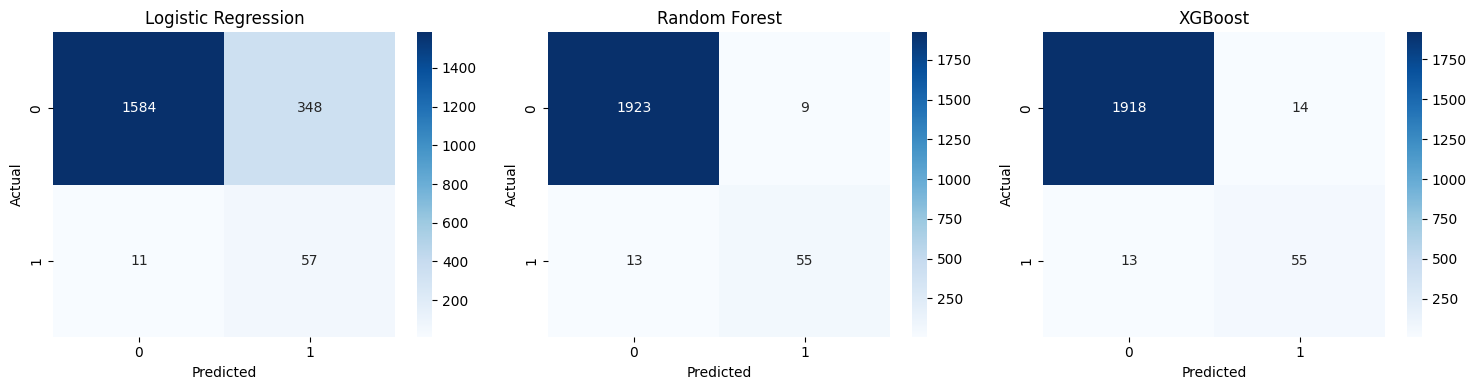

In [9]:
# Confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
preds = [y_pred_lr, y_pred_rf, y_pred_xgb]

for ax, name, pred in zip(axes, models, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('data/confusion_matrices.png', dpi=150)
plt.show()

In [11]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(model_rf, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Best model (Random Forest) and scaler saved to models/")

Best model (Random Forest) and scaler saved to models/
